# Task 2: Vision Task - Assignment-Aligned Emotion Recognition Notebook

**Dataset:** Facial expression classification  
**Goal:** Classify facial expressions into emotion classes with (A) CNNs built from scratch and (B) a fine-tuned pre-trained model inspired by the uploaded `facial-expression-based-emotion-recognition` notebook.

This notebook is organized to match the assignment tasks:
- dataset understanding, cleaning, visualization, and preprocessing
- baseline CNN from scratch
- deeper CNN with regularization
- optimizer comparison and ablation study
- transfer learning and fine-tuning
- final comparative analysis



In [1]:
# Optional: mount Google Drive when running in Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Not running inside Google Colab. Skipping Drive mount.")

Mounted at /content/drive


In [2]:

import os
import random
import time
import zipfile
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

# ============================================================
# 1. Imports, reproducibility and environment check
# ============================================================
!pip install tensorflow # Install TensorFlow if not already present
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
    Rescaling, GlobalAveragePooling2D
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_recall_fscore_support
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Enable dynamic GPU memory growth to reduce the chance of runtime crashes.
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print(f"Could not set memory growth for {gpu}: {e}")

print("TensorFlow version:", tf.__version__)
print("GPU devices:", gpus)


TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
#  Locate dataset and verify split folders

from pathlib import Path

# Update these candidates to match where your dataset zip or extracted folder is stored.
ZIP_CANDIDATES = [
    "/content/drive/MyDrive/AI ML/facial expression classification.zip",
    "/content/drive/MyDrive/facial expression classification.zip",
]

EXTRACT_CANDIDATES = [
    "/content/facial_expressions_dataset/facial expression classification",
    "/content/facial expression classification",
    "/kaggle/input/facial-expression-classification/facial expression classification",
]

DEFAULT_EXTRACT_PARENT = "/content/facial_expressions_dataset"

def find_existing_data_root(extract_candidates):
    for candidate in extract_candidates:
        candidate = Path(candidate)
        if candidate.exists() and (candidate / "train").exists():
            return str(candidate)
    return None

DATA_ROOT = find_existing_data_root(EXTRACT_CANDIDATES)

if DATA_ROOT is None:
    zip_path = next((p for p in ZIP_CANDIDATES if os.path.exists(p)), None)
    if zip_path is None:
        raise FileNotFoundError(
            "Dataset not found. Update ZIP_CANDIDATES or EXTRACT_CANDIDATES so the notebook can find your dataset."
        )

    os.makedirs(DEFAULT_EXTRACT_PARENT, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(DEFAULT_EXTRACT_PARENT)

    DATA_ROOT = find_existing_data_root([
        str(Path(DEFAULT_EXTRACT_PARENT) / "facial expression classification"),
        DEFAULT_EXTRACT_PARENT
    ])

    if DATA_ROOT is None:
        raise FileNotFoundError("Extraction finished but train/validation/test folders were not found.")

print("Resolved dataset root:", DATA_ROOT)

train_data_dir = os.path.join(DATA_ROOT, "train")
validation_data_dir = os.path.join(DATA_ROOT, "validation")
test_data_dir = os.path.join(DATA_ROOT, "test")

for path in [train_data_dir, validation_data_dir, test_data_dir]:
    print(path, "exists:", os.path.exists(path))

Resolved dataset root: /content/facial_expressions_dataset/facial expression classification
/content/facial_expressions_dataset/facial expression classification/train exists: True
/content/facial_expressions_dataset/facial expression classification/validation exists: True
/content/facial_expressions_dataset/facial expression classification/test exists: True


## Dataset understanding and cleaning

The dataset contains facial images grouped by emotion class.  
Typical classes in this dataset are: `angry`, `disgust`, `fear`, `happy`, `neutral`, `sad`, and `surprise`.

This notebook uses the provided folder split:
- **train** for model fitting
- **validation** for tuning and early stopping
- **test** for final evaluation only

This is a good assignment-aligned split because the validation set stays separate from the test set, so model-selection decisions do not leak test information.

Preprocessing choices used later:
- resize images to **48×48 grayscale** for CNNs built from scratch
- normalize pixel values with `Rescaling(1./255)`
- apply mild data augmentation to improve generalization
- convert grayscale images to **224×224 RGB** for transfer learning so the pre-trained backbone can use ImageNet weights

In [ ]:
#  Dataset counting and corrupted image cleaning
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

def count_images_by_class(data_dir):
    counts = {}
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(IMAGE_EXTENSIONS)
            ])
    return counts

def count_total_images(root_dir):
    total = 0
    for split in ["train", "validation", "test"]:
        split_dir = os.path.join(root_dir, split)
        if os.path.exists(split_dir):
            total += sum(count_images_by_class(split_dir).values())
    return total

def find_bad_images(root_dir):
    bad_files = []
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            if fname.lower().endswith(IMAGE_EXTENSIONS):
                fpath = os.path.join(dirpath, fname)
                try:
                    with Image.open(fpath) as img:
                        img.verify()
                except Exception as e:
                    bad_files.append((fpath, str(e)))
    return pd.DataFrame(bad_files, columns=["file_path", "error"])

def remove_bad_images(bad_df):
    removed = 0
    for path in bad_df["file_path"]:
        if os.path.exists(path):
            os.remove(path)
            removed += 1
    return removed

print("Total images before cleaning:", count_total_images(DATA_ROOT))

bad_train = find_bad_images(train_data_dir)
bad_val = find_bad_images(validation_data_dir)
bad_test = find_bad_images(test_data_dir)

print("Bad train images:", len(bad_train))
print("Bad validation images:", len(bad_val))
print("Bad test images:", len(bad_test))

removed = remove_bad_images(bad_train) + remove_bad_images(bad_val) + remove_bad_images(bad_test)
print("Removed corrupted images:", removed)
print("Total images after cleaning:", count_total_images(DATA_ROOT))

Total images before cleaning: 35887
Bad train images: 49
Bad validation images: 0
Bad test images: 0
Removed corrupted images: 49
Total images after cleaning: 35838


,train,validation,test
angry,3686,960,300
disgust,329,111,100
fear,3796,1018,300
happy,6857,1825,300
neutral,4675,1216,300
sad,4631,1139,300
surprise,2898,797,300
TOTAL,26872,7066,1900


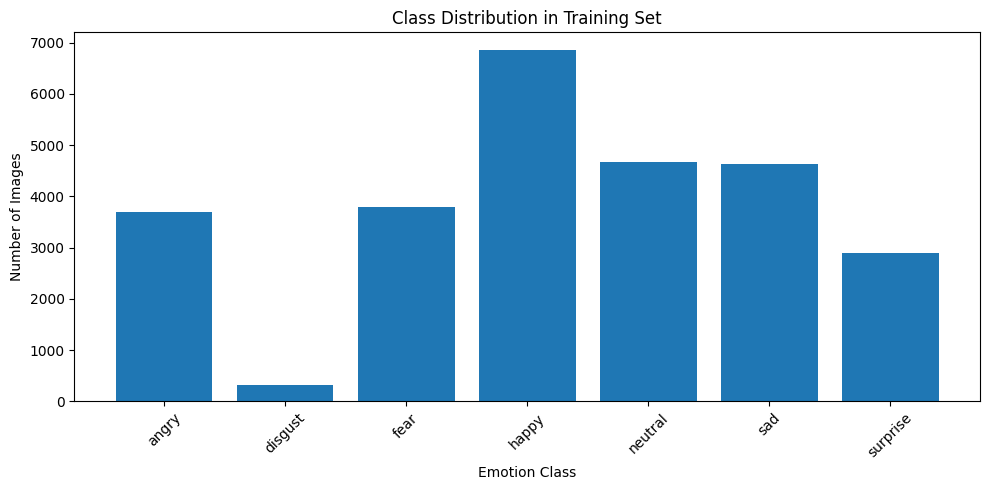

In [ ]:
#  Class distribution

train_class_counts = count_images_by_class(train_data_dir)
val_class_counts = count_images_by_class(validation_data_dir)
test_class_counts = count_images_by_class(test_data_dir)

distribution_df = pd.DataFrame({
    "train": train_class_counts,
    "validation": val_class_counts,
    "test": test_class_counts
}).fillna(0).astype(int)

distribution_df.loc["TOTAL"] = distribution_df.sum(axis=0)
display(distribution_df)

plt.figure(figsize=(10, 5))
plt.bar(train_class_counts.keys(), train_class_counts.values())
plt.title("Class Distribution in Training Set")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

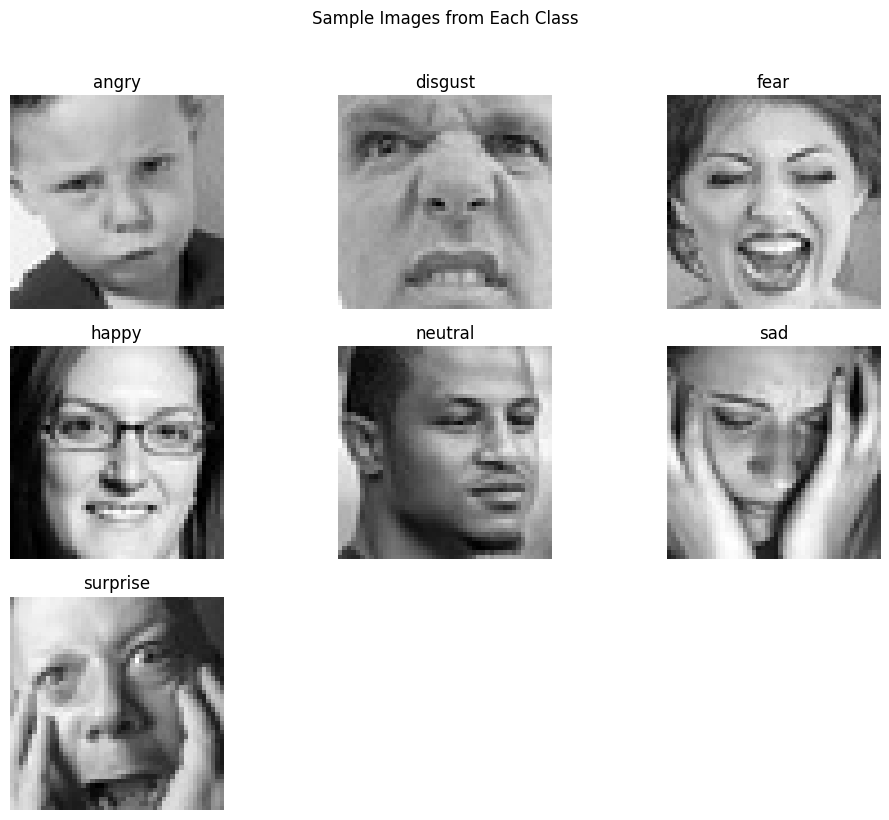

In [ ]:
#  Visualize one sample image from each class

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(sorted(os.listdir(train_data_dir)), start=1):
    class_path = os.path.join(train_data_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(IMAGE_EXTENSIONS)]
    if len(image_files) == 0:
        continue

    img_path = os.path.join(class_path, random.choice(image_files))
    img = Image.open(img_path)

    plt.subplot(3, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Sample Images from Each Class", y=1.02)
plt.tight_layout()
plt.show()

## Preprocessing and augmentation

Important fixes made here:
- The facial-expression images are grayscale, so the scratch CNN uses `color_mode="grayscale"` and input shape `(48, 48, 1)`.
- Images are normalized inside the model with `Rescaling(1./255)`.
- Augmentation is kept mild because facial expressions can be distorted by aggressive rotation or zoom.
- Class weights are computed to reduce bias toward majority classes, but the weights are smoothed to avoid over-correcting the minority classes.

In [ ]:
#  TensorFlow datasets

IMG_SIZE = (48, 48)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_raw = tf.keras.utils.image_dataset_from_directory(
    train_data_dir,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_raw = tf.keras.utils.image_dataset_from_directory(
    validation_data_dir,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_raw = tf.keras.utils.image_dataset_from_directory(
    test_data_dir,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_raw.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

# Save labels before applying cache/shuffle/prefetch.
y_train_flat = np.concatenate([labels.numpy() for _, labels in train_raw], axis=0)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train_flat
)

# Smoothing prevents the rarest class from dominating training too strongly.
smoothed_class_weights_array = np.sqrt(class_weights_array)
class_weights = dict(enumerate(smoothed_class_weights_array))

print("Smoothed class weights:")
for i, weight in class_weights.items():
    print(f"{class_names[i]}: {weight:.4f}")

train_ds = train_raw.cache().shuffle(2000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_raw.cache().prefetch(AUTOTUNE)
test_ds = test_raw.cache().prefetch(AUTOTUNE)

Found 26872 files belonging to 7 classes.
Found 7066 files belonging to 7 classes.
Found 1900 files belonging to 7 classes.
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7
Smoothed class weights:
angry: 1.0205
disgust: 3.4159
fear: 1.0056
happy: 0.7482
neutral: 0.9062
sad: 0.9105
surprise: 1.1509


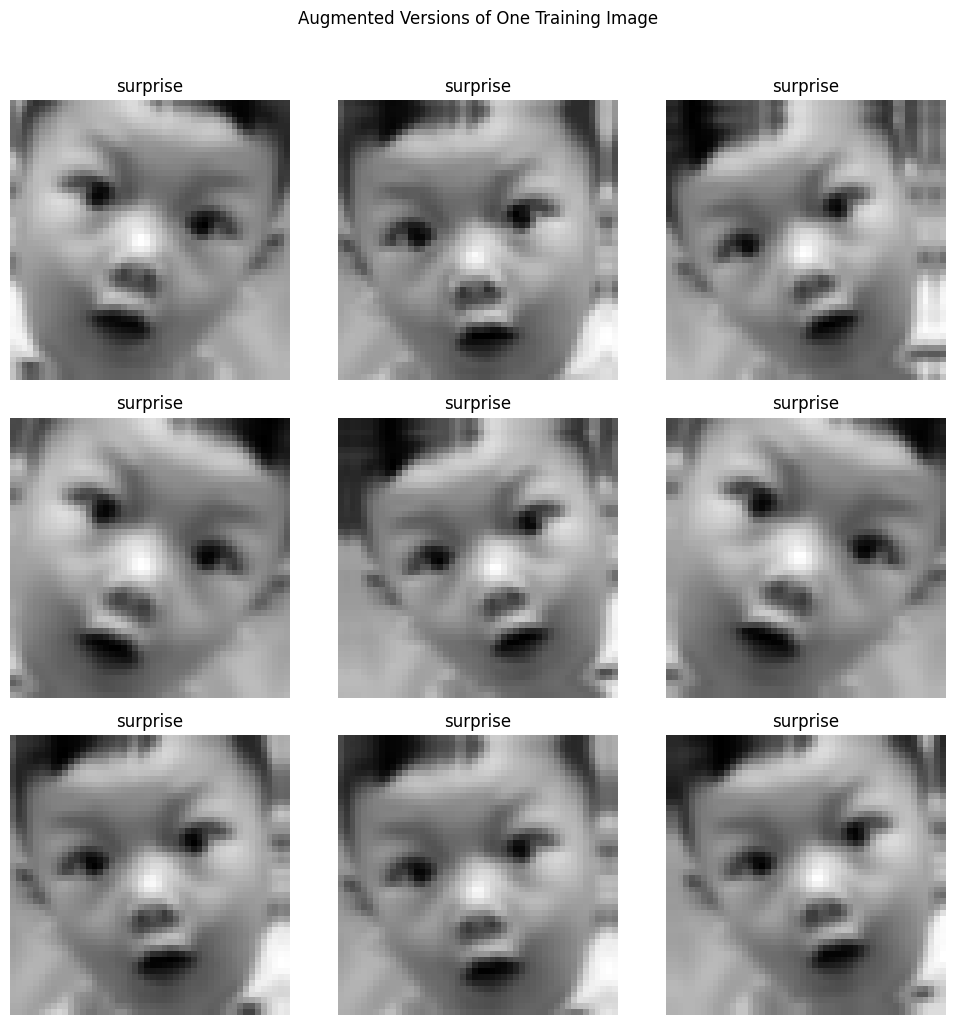

In [ ]:
#  Data augmentation visualization

data_augmentation = Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.04, seed=SEED),
    layers.RandomZoom(0.08, seed=SEED),
    layers.RandomTranslation(0.04, 0.04, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name="mild_data_augmentation")

for images, labels in train_ds.take(1):
    first_image = images[0]

    plt.figure(figsize=(10, 10))
    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0), training=True)
        plt.subplot(3, 3, i + 1)
        plt.imshow(tf.squeeze(augmented_image[0]), cmap="gray")
        plt.title(class_names[int(labels[0])])
        plt.axis("off")

    plt.suptitle("Augmented Versions of One Training Image", y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
#  Reusable evaluation and plotting helper functions

def plot_history(history, title_prefix):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(9, 5))
    plt.plot(hist["loss"], label="Training Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix}: Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    if "accuracy" in hist.columns:
        plt.figure(figsize=(9, 5))
        plt.plot(hist["accuracy"], label="Training Accuracy")
        plt.plot(hist["val_accuracy"], label="Validation Accuracy")
        plt.title(f"{title_prefix}: Training vs Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

def get_true_labels(dataset):
    return np.concatenate([labels.numpy() for _, labels in dataset], axis=0)

def evaluate_model(model, dataset, class_names, model_name):
    y_true = get_true_labels(dataset)
    y_prob = model.predict(dataset, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    loss, accuracy = model.evaluate(dataset, verbose=0)

    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    print(f"\n{model_name} Evaluation")
    print("-" * 60)
    print(f"Test loss: {loss:.4f}")
    print(f"Test accuracy: {accuracy:.4f}")
    print(f"Weighted precision: {precision_w:.4f}")
    print(f"Weighted recall: {recall_w:.4f}")
    print(f"Weighted F1-score: {f1_w:.4f}")
    print(f"Macro precision: {precision_m:.4f}")
    print(f"Macro recall: {recall_m:.4f}")
    print(f"Macro F1-score: {f1_m:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
    plt.title(f"{model_name}: Confusion Matrix")
    plt.tight_layout()
    plt.show()

    metrics_dict = {
        "Model": model_name,
        "Test Loss": loss,
        "Test Accuracy": accuracy,
        "Weighted Precision": precision_w,
        "Weighted Recall": recall_w,
        "Weighted F1": f1_w,
        "Macro Precision": precision_m,
        "Macro Recall": recall_m,
        "Macro F1": f1_m,
    }
    return metrics_dict, y_true, y_pred, y_prob

def plot_sample_predictions(model, dataset, class_names, title, n=9):
    for images, labels in dataset.take(1):
        probabilities = model.predict(images, verbose=0)
        predictions = np.argmax(probabilities, axis=1)

        plt.figure(figsize=(12, 10))
        for i in range(min(n, len(images))):
            plt.subplot(3, 3, i + 1)

            image_np = images[i].numpy()
            if image_np.shape[-1] == 1:
                plt.imshow(tf.squeeze(image_np), cmap="gray")
            else:
                plt.imshow(image_np.astype("uint8"))

            true_label = class_names[int(labels[i])]
            pred_label = class_names[int(predictions[i])]
            confidence = float(np.max(probabilities[i]))
            color = "green" if true_label == pred_label else "red"

            plt.title(
                f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})",
                color=color
            )
            plt.axis("off")

        plt.suptitle(title, y=1.02)
        plt.tight_layout()
        plt.show()
        break

def make_callbacks(prefix, monitor="val_loss", mode="min", patience=8):
    return [
        ModelCheckpoint(
            f"{prefix}_best.keras",
            monitor=monitor,
            save_best_only=True,
            mode=mode,
            verbose=1
        ),
        EarlyStopping(
            monitor=monitor,
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            factor=0.3,
            patience=max(2, patience // 2),
            min_lr=1e-6,
            verbose=1
        )
    ]

# Part A: CNN models from scratch

## Baseline CNN

The baseline is intentionally simple and follows the guideline structure: three convolutional layers, each followed by pooling, then three fully connected layers and a softmax output layer.

In [ ]:
#  Baseline CNN model

def build_baseline_model():
    model = Sequential([
        layers.Input(shape=(48, 48, 1)),
        data_augmentation,
        Rescaling(1./255),

        Conv2D(32, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(256, activation="relu"),
        Dropout(0.30),
        Dense(128, activation="relu"),
        Dropout(0.20),
        Dense(64, activation="relu"),

        Dense(num_classes, activation="softmax")
    ], name="baseline_cnn")

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mild_data_augmentation          │ (None, 48, 48, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,183 (5.01 MB)

 Trainable params: 1,314,183 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  Train baseline model

BASELINE_EPOCHS = 30

start_time = time.time()
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("baseline", monitor="val_loss", mode="min", patience=8),
    verbose=1
)
baseline_training_time = time.time() - start_time

print(f"Baseline training time: {baseline_training_time:.2f} seconds")

Epoch 1/30
416/420 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2231 - loss: 1.8123
Epoch 1: val_loss improved from None to 1.77881, saving model to baseline_best.keras

Epoch 1: finished saving model to baseline_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.2423 - loss: 1.7856 - val_accuracy: 0.2980 - val_loss: 1.7788 - learning_rate: 0.0010
Epoch 2/30
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2990 - loss: 1.6919
Epoch 2: val_loss improved from 1.77881 to 1.58516, saving model to baseline_best.keras

Epoch 2: finished saving model to baseline_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3174 - loss: 1.6697 - val_accuracy: 0.3861 - val_loss: 1.5852 - learning_rate: 0.0010
Epoch 3/30
417/420 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3713 - loss: 1.5839
Epoch 3: val_loss improved from 1.58516 to 1.47378, saving model to baseline_best.keras

Epoch 3: finished saving model to baseline_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━

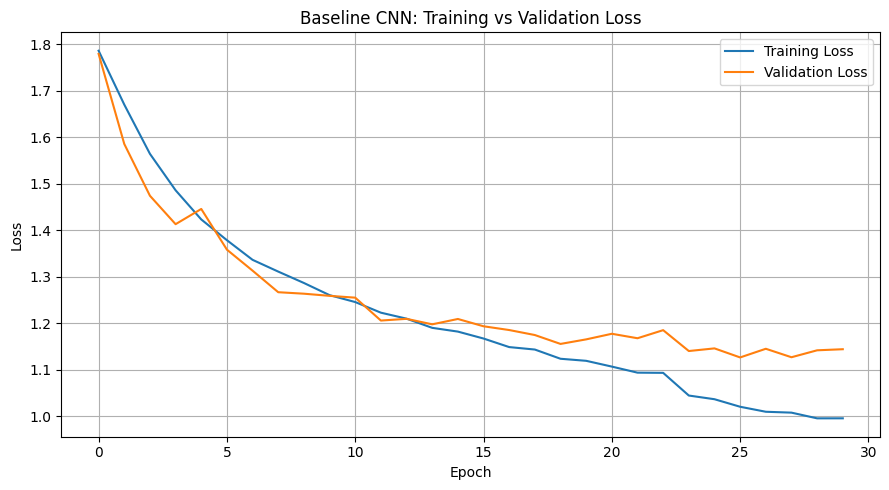

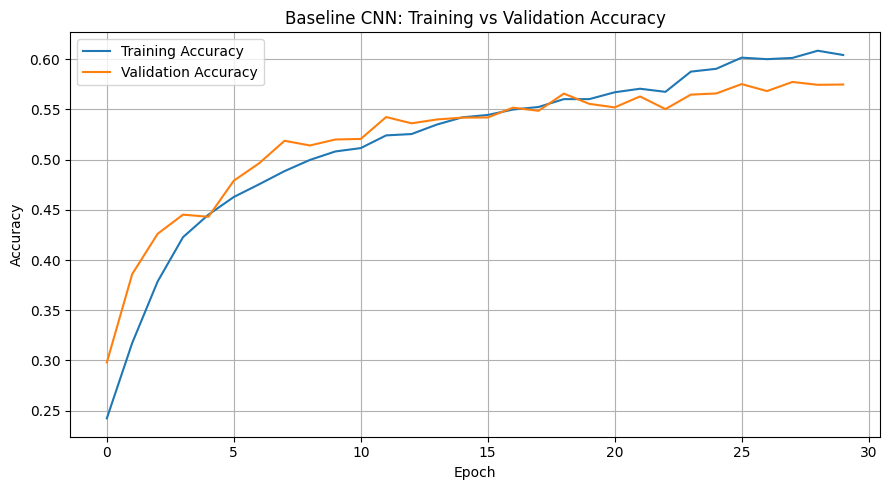


Baseline CNN Evaluation
------------------------------------------------------------
Test loss: 1.2697
Test accuracy: 0.5305
Weighted precision: 0.5223
Weighted recall: 0.5305
Weighted F1-score: 0.5208
Macro precision: 0.5387
Macro recall: 0.5190
Macro F1-score: 0.5203

Classification Report:
              precision    recall  f1-score   support

       angry       0.47      0.45      0.46       300
     disgust       0.69      0.41      0.52       100
        fear       0.37      0.25      0.30       300
       happy       0.68      0.78      0.73       300
     neutral       0.47      0.59      0.52       300
         sad       0.40      0.40      0.40       300
    surprise       0.69      0.76      0.72       300

    accuracy                           0.53      1900
   macro avg       0.54      0.52      0.52      1900
weighted avg       0.52      0.53      0.52      1900



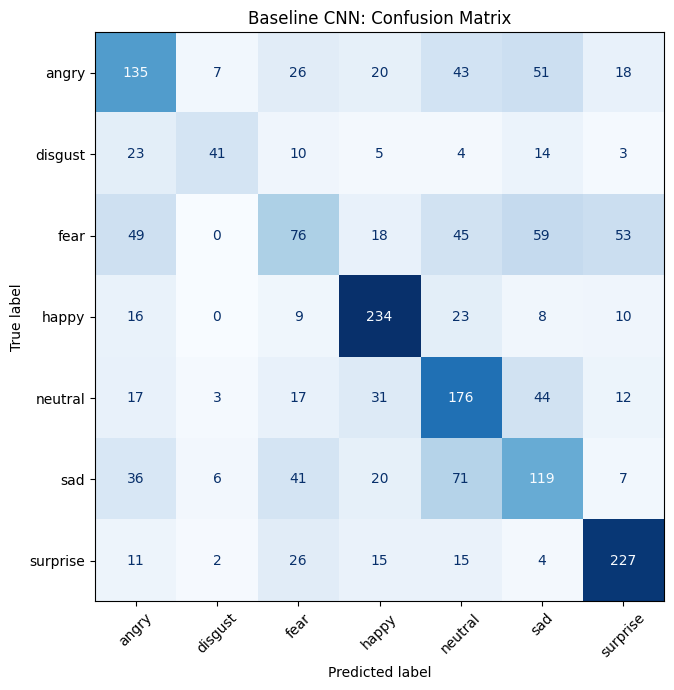

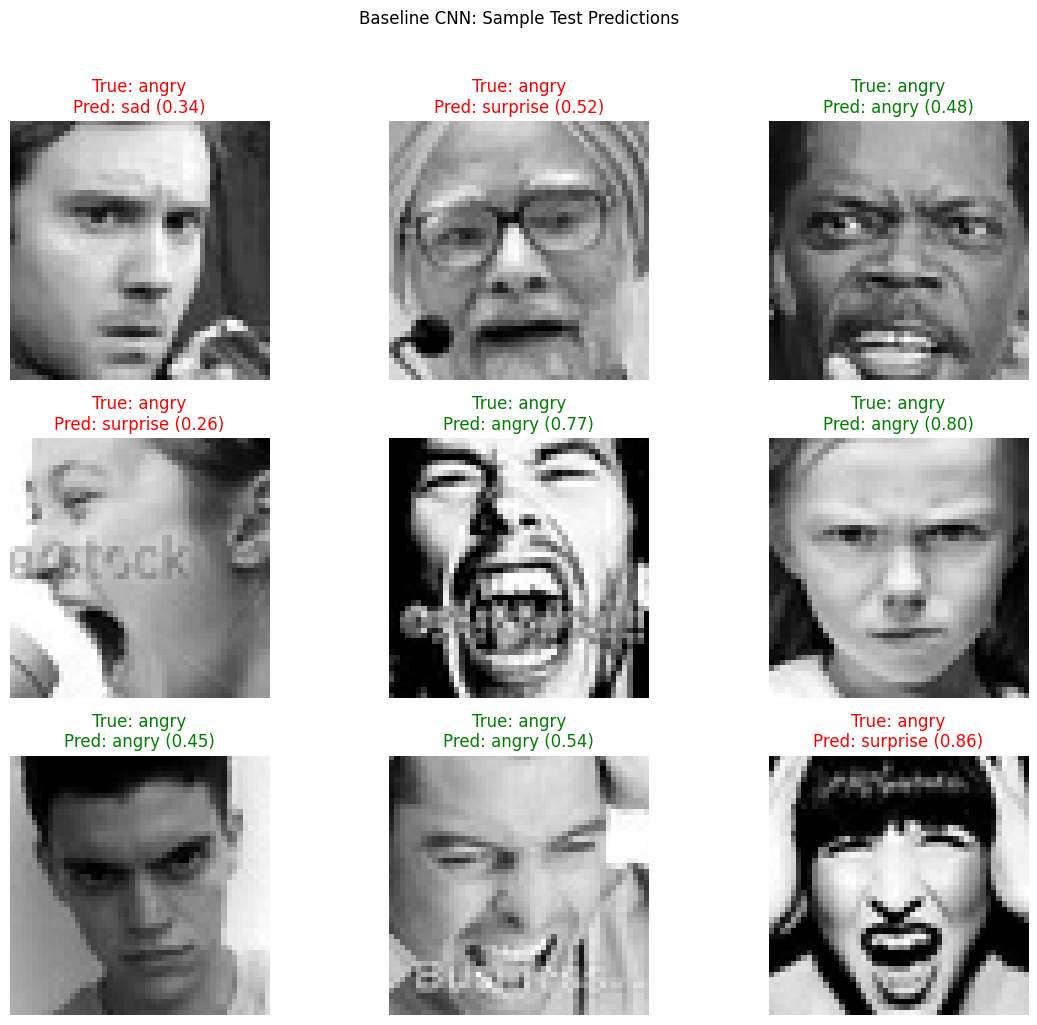

In [12]:
plot_history(baseline_history, "Baseline CNN")

baseline_metrics, baseline_y_true, baseline_y_pred, baseline_y_prob = evaluate_model(
    baseline_model, test_ds, class_names, "Baseline CNN"
)

plot_sample_predictions(
    baseline_model, test_ds, class_names,
    title="Baseline CNN: Sample Test Predictions"
)

## Deeper CNN with regularization

The deeper model has more than double the number of convolutional layers compared with the baseline. The main improvements are:
- **Batch Normalization** to stabilize training.
- **Dropout** after pooling and dense layers to reduce overfitting.
- **L2 regularization** to discourage overly large weights.
- **GlobalAveragePooling2D** instead of a large Flatten layer to reduce parameters and improve generalization.
- **ReduceLROnPlateau** to lower the learning rate when validation loss stops improving.

In [13]:
# ============================================================
# 11. Deeper CNN model with regularization
# ============================================================
def conv_bn_relu(x, filters, kernel_size=(3, 3), l2_strength=1e-4):
    x = Conv2D(
        filters,
        kernel_size,
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizers.l2(l2_strength)
    )(x)
    x = BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def build_deeper_model(optimizer=None, include_dropout=True, include_batchnorm=True):
    inputs = layers.Input(shape=(48, 48, 1))
    x = data_augmentation(inputs)
    x = Rescaling(1./255)(x)

    # Block 1: 2 convolutional layers
    if include_batchnorm:
        x = conv_bn_relu(x, 32)
        x = conv_bn_relu(x, 32)
    else:
        x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
        x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)
    if include_dropout:
        x = Dropout(0.20)(x)

    # Block 2: 2 convolutional layers
    if include_batchnorm:
        x = conv_bn_relu(x, 64)
        x = conv_bn_relu(x, 64)
    else:
        x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
        x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)
    if include_dropout:
        x = Dropout(0.25)(x)

    # Block 3: 2 convolutional layers
    if include_batchnorm:
        x = conv_bn_relu(x, 128)
        x = conv_bn_relu(x, 128)
    else:
        x = Conv2D(128, (3,3), activation="relu", padding="same")(x)
        x = Conv2D(128, (3,3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)
    if include_dropout:
        x = Dropout(0.30)(x)

    # Block 4: 2 convolutional layers
    if include_batchnorm:
        x = conv_bn_relu(x, 256)
        x = conv_bn_relu(x, 256)
    else:
        x = Conv2D(256, (3,3), activation="relu", padding="same")(x)
        x = Conv2D(256, (3,3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)
    if include_dropout:
        x = Dropout(0.35)(x)

    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    if include_dropout:
        x = Dropout(0.45)(x)
    x = Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    if include_dropout:
        x = Dropout(0.30)(x)
    x = Dense(64, activation="relu")(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="deeper_regularized_cnn")

    if optimizer is None:
        optimizer = Adam(learning_rate=1e-3)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

deeper_model = build_deeper_model()
deeper_model.summary()

Model: "deeper_regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mild_data_augmentation          │ (None, 48, 48, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             

 Total params: 1,281,959 (4.89 MB)

 Trainable params: 1,280,039 (4.88 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
#  Train deeper model

DEEPER_EPOCHS = 60

start_time = time.time()
deeper_history = deeper_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=DEEPER_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("deeper_cnn", monitor="val_loss", mode="min", patience=10),
    verbose=1
)
deeper_training_time = time.time() - start_time

print(f"Deeper model training time: {deeper_training_time:.2f} seconds")

Epoch 1/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2245 - loss: 1.9385
Epoch 1: val_loss improved from None to 1.90452, saving model to deeper_cnn_best.keras

Epoch 1: finished saving model to deeper_cnn_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 26s 44ms/step - accuracy: 0.2493 - loss: 1.8820 - val_accuracy: 0.2646 - val_loss: 1.9045 - learning_rate: 0.0010
Epoch 2/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3090 - loss: 1.7823
Epoch 2: val_loss improved from 1.90452 to 1.73909, saving model to deeper_cnn_best.keras

Epoch 2: finished saving model to deeper_cnn_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.3233 - loss: 1.7556 - val_accuracy: 0.3341 - val_loss: 1.7391 - learning_rate: 0.0010
Epoch 3/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3775 - loss: 1.6530
Epoch 3: val_loss improved from 1.73909 to 1.68160, saving model to deeper_cnn_best.keras

Epoch 3: finished saving model to deeper_cnn_best.keras
420/420 ━━━━━━━

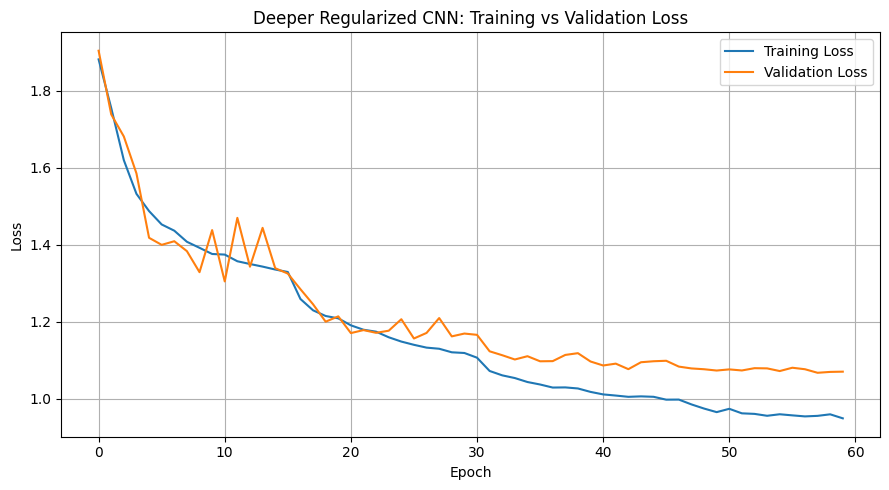

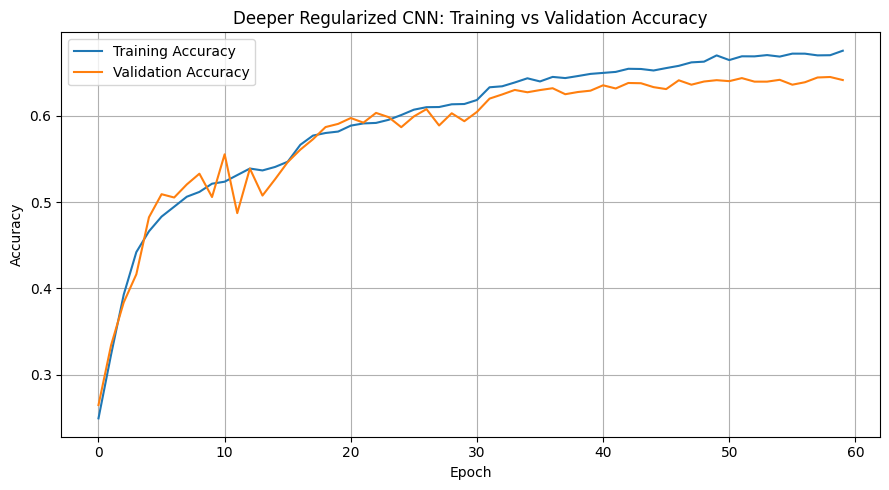


Deeper Regularized CNN Evaluation
------------------------------------------------------------
Test loss: 1.2130
Test accuracy: 0.5926
Weighted precision: 0.5991
Weighted recall: 0.5926
Weighted F1-score: 0.5869
Macro precision: 0.6269
Macro recall: 0.5829
Macro F1-score: 0.5912

Classification Report:
              precision    recall  f1-score   support

       angry       0.53      0.54      0.54       300
     disgust       0.89      0.49      0.63       100
        fear       0.45      0.29      0.36       300
       happy       0.77      0.83      0.80       300
     neutral       0.48      0.69      0.56       300
         sad       0.50      0.49      0.49       300
    surprise       0.78      0.75      0.76       300

    accuracy                           0.59      1900
   macro avg       0.63      0.58      0.59      1900
weighted avg       0.60      0.59      0.59      1900



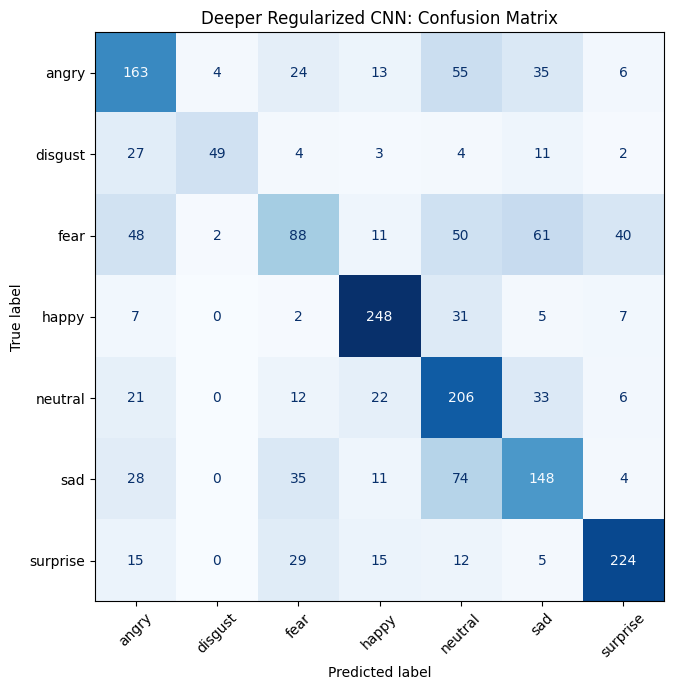

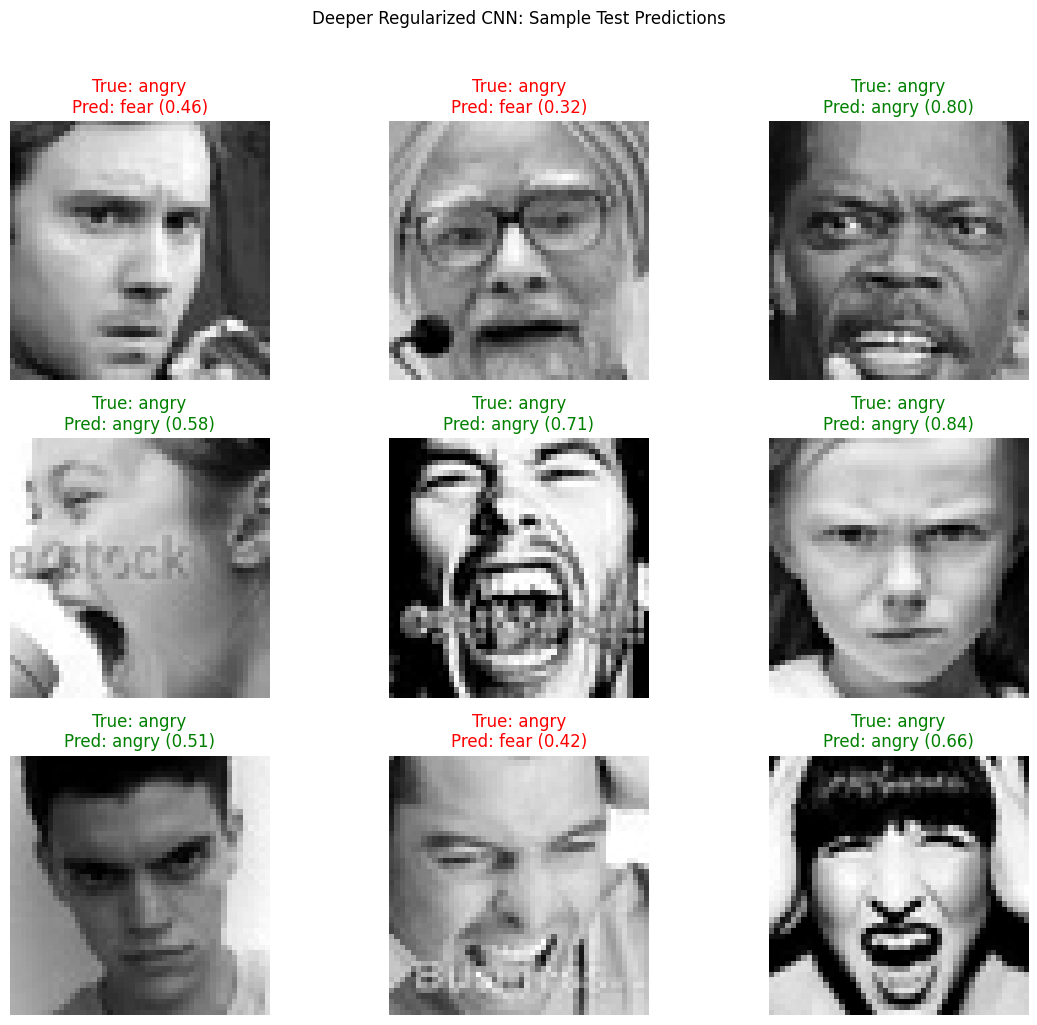

In [15]:
plot_history(deeper_history, "Deeper Regularized CNN")

deeper_metrics, deeper_y_true, deeper_y_pred, deeper_y_prob = evaluate_model(
    deeper_model, test_ds, class_names, "Deeper Regularized CNN"
)

plot_sample_predictions(
    deeper_model, test_ds, class_names,
    title="Deeper Regularized CNN: Sample Test Predictions"
)

## Optimizer analysis: SGD vs Adam

Both models below use the same deeper architecture and the same data pipeline. This makes the comparison fairer because the optimizer is the main changed variable.

Epoch 1/25
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2191 - loss: 1.9478
Epoch 1: val_loss improved from None to 1.94878, saving model to deeper_sgd_best.keras

Epoch 1: finished saving model to deeper_sgd_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.2317 - loss: 1.9132 - val_accuracy: 0.2583 - val_loss: 1.9488 - learning_rate: 0.0100
Epoch 2/25
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2679 - loss: 1.8811
Epoch 2: val_loss improved from 1.94878 to 1.80764, saving model to deeper_sgd_best.keras

Epoch 2: finished saving model to deeper_sgd_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.2803 - loss: 1.8476 - val_accuracy: 0.3142 - val_loss: 1.8076 - learning_rate: 0.0100
Epoch 3/25
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3083 - loss: 1.7987
Epoch 3: val_loss did not improve from 1.80764
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.3159 - loss: 1.7737 - val_accuracy: 0.3106 - val_loss: 1.8

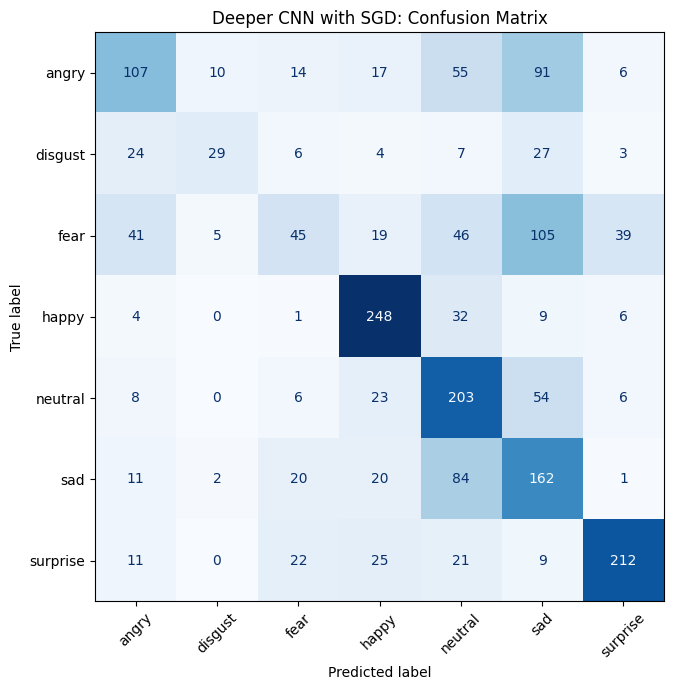

Epoch 1/25
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2130 - loss: 1.9547
Epoch 1: val_loss improved from None to 1.96385, saving model to deeper_adam_best.keras

Epoch 1: finished saving model to deeper_adam_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 24s 42ms/step - accuracy: 0.2320 - loss: 1.9087 - val_accuracy: 0.2580 - val_loss: 1.9639 - learning_rate: 0.0010
Epoch 2/25
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2838 - loss: 1.8130
Epoch 2: val_loss improved from 1.96385 to 1.77381, saving model to deeper_adam_best.keras

Epoch 2: finished saving model to deeper_adam_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.3022 - loss: 1.7905 - val_accuracy: 0.3234 - val_loss: 1.7738 - learning_rate: 0.0010
Epoch 3/25
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3640 - loss: 1.6843
Epoch 3: val_loss improved from 1.77381 to 1.60201, saving model to deeper_adam_best.keras

Epoch 3: finished saving model to deeper_adam_best.keras
420/420 ━

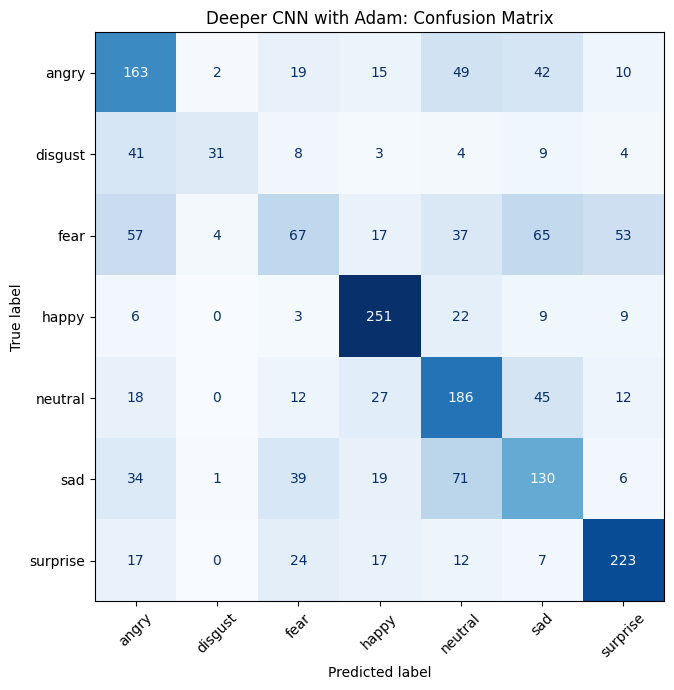

,Model,Test Loss,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1,Training Time (seconds)
0,Deeper CNN with SGD,1.357612,0.529474,0.537647,0.529474,0.511513,0.546484,0.506667,0.500632,404.278571
1,Deeper CNN with Adam,1.276665,0.553158,0.549615,0.553158,0.539554,0.574965,0.530000,0.530956,447.227128


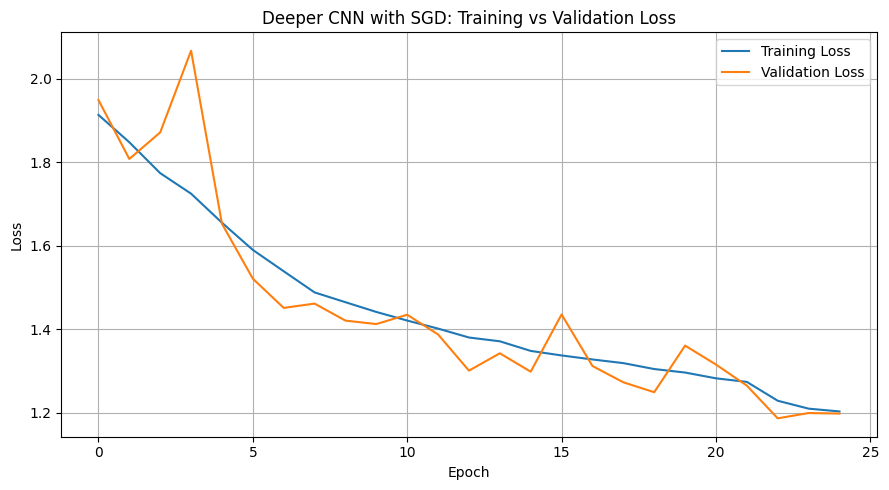

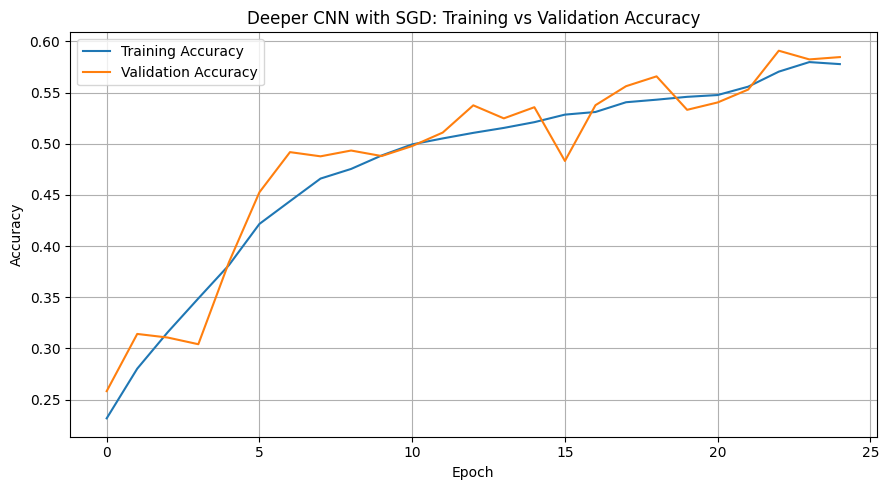

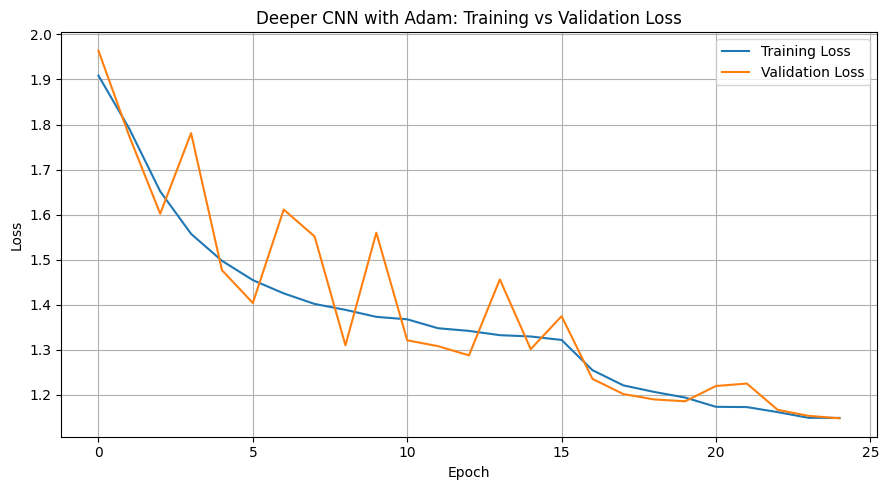

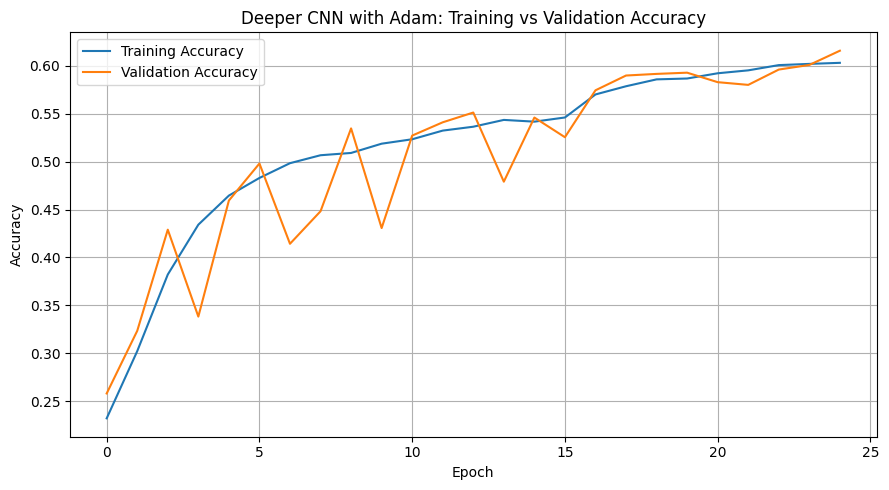

In [ ]:
#  Optimizer comparison
OPTIMIZER_EPOCHS = 25

optimizer_results = []

# SGD with momentum
sgd_model = build_deeper_model(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
)

start_time = time.time()
sgd_history = sgd_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=OPTIMIZER_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("deeper_sgd", monitor="val_loss", mode="min", patience=6),
    verbose=1
)
sgd_training_time = time.time() - start_time

sgd_metrics, _, _, _ = evaluate_model(sgd_model, test_ds, class_names, "Deeper CNN with SGD")
sgd_metrics["Training Time (seconds)"] = sgd_training_time
optimizer_results.append(sgd_metrics)

# Adam
adam_model = build_deeper_model(
    optimizer=Adam(learning_rate=1e-3)
)

start_time = time.time()
adam_history = adam_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=OPTIMIZER_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("deeper_adam", monitor="val_loss", mode="min", patience=6),
    verbose=1
)
adam_training_time = time.time() - start_time

adam_metrics, _, _, _ = evaluate_model(adam_model, test_ds, class_names, "Deeper CNN with Adam")
adam_metrics["Training Time (seconds)"] = adam_training_time
optimizer_results.append(adam_metrics)

optimizer_df = pd.DataFrame(optimizer_results)
display(optimizer_df)

plot_history(sgd_history, "Deeper CNN with SGD")
plot_history(adam_history, "Deeper CNN with Adam")

## Ablation study: removing dropout

Dropout is removed from the deeper CNN while keeping the rest of the model similar. If validation performance becomes worse or the training-validation gap increases, it suggests that dropout was helping the model generalize.

Model: "deeper_regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mild_data_augmentation          │ (None, 48, 48, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 48, 48, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 48, 48, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 24, 24, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 24, 24, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 12, 12, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 12, 12, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 12, 12, 128)    │           51

 Total params: 1,281,959 (4.89 MB)

 Trainable params: 1,280,039 (4.88 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/25
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2868 - loss: 1.8460
Epoch 1: val_loss improved from None to 2.25425, saving model to ablation_no_dropout_best.keras

Epoch 1: finished saving model to ablation_no_dropout_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.3472 - loss: 1.7311 - val_accuracy: 0.3596 - val_loss: 2.2542 - learning_rate: 0.0010
Epoch 2/25
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4646 - loss: 1.5098
Epoch 2: val_loss improved from 2.25425 to 1.48110, saving model to ablation_no_dropout_best.keras

Epoch 2: finished saving model to ablation_no_dropout_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.4754 - loss: 1.4724 - val_accuracy: 0.4608 - val_loss: 1.4811 - learning_rate: 0.0010
Epoch 3/25
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5028 - loss: 1.4059
Epoch 3: val_loss improved from 1.48110 to 1.37629, saving model to ablation_no_dropout_best.keras

Epoch 3: finished saving m

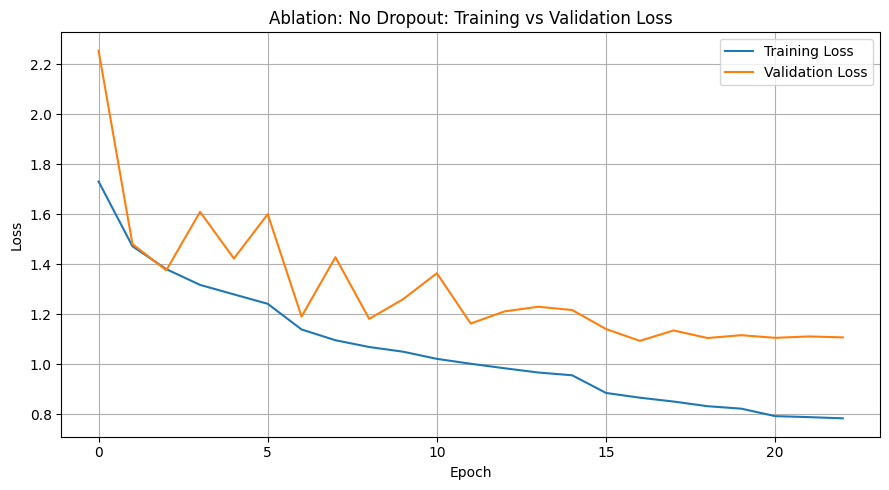

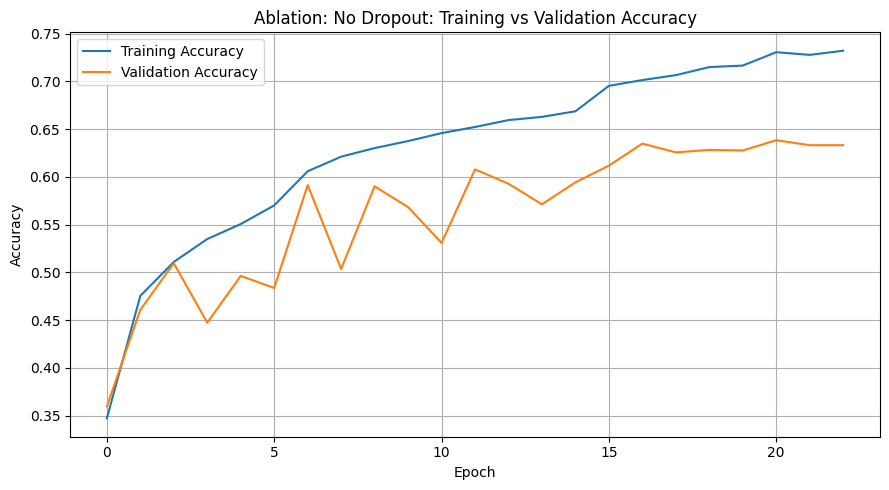


Ablation: Deeper CNN without Dropout Evaluation
------------------------------------------------------------
Test loss: 1.2428
Test accuracy: 0.5905
Weighted precision: 0.5962
Weighted recall: 0.5905
Weighted F1-score: 0.5853
Macro precision: 0.6188
Macro recall: 0.5724
Macro F1-score: 0.5810

Classification Report:
              precision    recall  f1-score   support

       angry       0.56      0.54      0.55       300
     disgust       0.83      0.40      0.54       100
        fear       0.47      0.35      0.40       300
       happy       0.78      0.79      0.78       300
     neutral       0.48      0.66      0.56       300
         sad       0.48      0.48      0.48       300
    surprise       0.72      0.80      0.76       300

    accuracy                           0.59      1900
   macro avg       0.62      0.57      0.58      1900
weighted avg       0.60      0.59      0.59      1900



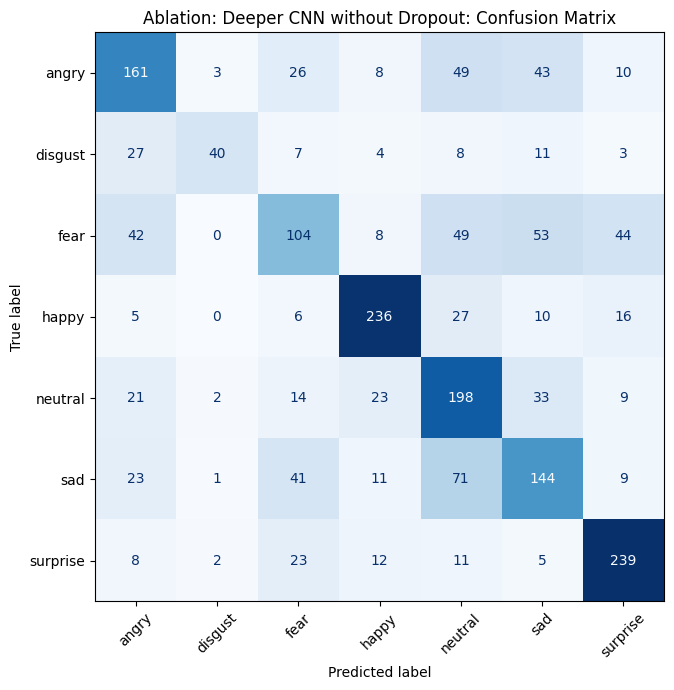

In [ ]:
#  Ablation study: deeper model without dropout

ablation_no_dropout_model = build_deeper_model(
    optimizer=Adam(learning_rate=1e-3),
    include_dropout=False,
    include_batchnorm=True
)

ablation_no_dropout_model.summary()

ABLATION_EPOCHS = 25

start_time = time.time()
ablation_history = ablation_no_dropout_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=ABLATION_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("ablation_no_dropout", monitor="val_loss", mode="min", patience=6),
    verbose=1
)
ablation_training_time = time.time() - start_time

plot_history(ablation_history, "Ablation: No Dropout")

ablation_metrics, _, _, _ = evaluate_model(
    ablation_no_dropout_model,
    test_ds,
    class_names,
    "Ablation: Deeper CNN without Dropout"
)
ablation_metrics["Training Time (seconds)"] = ablation_training_time

# Part B: Transfer learning

This section adapts ideas from the uploaded `facial-expression-based-emotion-recognition` notebook while keeping the workflow aligned with the assignment.

Key improvements over the earlier transfer-learning block:
- use a stronger **MobileNetV3Small** ImageNet backbone
- convert grayscale images to **160*160 RGB** for compatibility with the pre-trained model
- add a lightweight **PointAttention** block after the convolutional base
- train in two stages:
  1. **feature extraction** with the backbone frozen
  2. **fine-tuning** by unfreezing only the upper layers with a smaller learning rate

This gives a more facial-expression-focused transfer-learning pipeline without breaking the assignment structure.

In [ ]:

#  Transfer learning datasets

TRANSFER_SIZE = (160, 160)
TRANSFER_BATCH_SIZE = 16

def build_transfer_dataset(data_dir, training=False):
    ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        image_size=TRANSFER_SIZE,
        color_mode="rgb",
        batch_size=TRANSFER_BATCH_SIZE,
        label_mode="int",
        shuffle=training,
        seed=SEED if training else None
    )
    return ds.prefetch(AUTOTUNE)

transfer_train_ds = build_transfer_dataset(train_data_dir, training=True)
transfer_val_ds = build_transfer_dataset(validation_data_dir, training=False)
transfer_test_ds = build_transfer_dataset(test_data_dir, training=False)

for batch_images, batch_labels in transfer_train_ds.take(1):
    print("Transfer batch image shape:", batch_images.shape)
    print("Transfer batch label shape:", batch_labels.shape)


Found 26872 files belonging to 7 classes.
Found 7066 files belonging to 7 classes.
Found 1900 files belonging to 7 classes.
Transfer batch image shape: (16, 160, 160, 3)
Transfer batch label shape: (16,)


In [19]:

# ============================================================
# 16. Build transfer learning model inspired by the FER notebook
# ============================================================
from tensorflow.keras.applications import MobileNetV3Small

@tf.keras.utils.register_keras_serializable()
class PointAttention(layers.Layer):
    def __init__(self, reduction_ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        channels = int(input_shape[-1])
        reduced_channels = max(channels // self.reduction_ratio, 8)

        self.gap = layers.GlobalAveragePooling2D()
        self.gmp = layers.GlobalMaxPooling2D()
        self.fc1 = layers.Dense(reduced_channels, activation="relu", use_bias=False)
        self.fc2 = layers.Dense(channels, use_bias=False)
        self.spatial_conv = layers.Conv2D(
            1, kernel_size=7, padding="same", activation="sigmoid", use_bias=False
        )
        super().build(input_shape)

    def call(self, inputs):
        avg = self.fc2(self.fc1(self.gap(inputs)))
        mx = self.fc2(self.fc1(self.gmp(inputs)))
        channel_attention = tf.nn.sigmoid(avg + mx)
        channel_attention = tf.reshape(channel_attention, (-1, 1, 1, tf.shape(inputs)[-1]))
        x = inputs * channel_attention

        avg_map = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_map = tf.reduce_max(x, axis=-1, keepdims=True)
        spatial_attention = self.spatial_conv(tf.concat([avg_map, max_map], axis=-1))
        return x * spatial_attention

    def get_config(self):
        config = super().get_config()
        config.update({"reduction_ratio": self.reduction_ratio})
        return config

transfer_augmentation = Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.05, seed=SEED),
    layers.RandomZoom(0.08, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name="transfer_augmentation")

def build_transfer_model(input_shape=(160, 160, 3), num_classes=7):
    base_model = MobileNetV3Small(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
        include_preprocessing=True
    )
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = transfer_augmentation(inputs)
    x = base_model(x, training=False)
    x = PointAttention(reduction_ratio=8, name="point_attention")(x)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = Dropout(0.35)(x)
    x = Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = Dropout(0.25)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="mobilenetv3small_pointattention")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

transfer_model, base_model = build_transfer_model(
    input_shape=(TRANSFER_SIZE[0], TRANSFER_SIZE[1], 3),
    num_classes=num_classes
)
transfer_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv3small_pointattention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_augmentation           │ (None, 160, 160, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 5, 5, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ point_attention                 │ (None, 5, 5, 576)      │        83,042 │
│ (PointAttention)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 576)            │         2,304 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,107,033 (4.22 MB)

 Trainable params: 166,761 (651.41 KB)

 Non-trainable params: 940,272 (3.59 MB)

Epoch 1/15
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3000 - loss: 1.7729
Epoch 1: val_accuracy improved from None to 0.44353, saving model to transfer_feature_extraction_best.keras

Epoch 1: finished saving model to transfer_feature_extraction_best.keras
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 49s 25ms/step - accuracy: 0.3413 - loss: 1.6785 - val_accuracy: 0.4435 - val_loss: 1.4997 - learning_rate: 0.0010
Epoch 2/15
1679/1680 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3991 - loss: 1.5754
Epoch 2: val_accuracy improved from 0.44353 to 0.45910, saving model to transfer_feature_extraction_best.keras

Epoch 2: finished saving model to transfer_feature_extraction_best.keras
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.3998 - loss: 1.5666 - val_accuracy: 0.4591 - val_loss: 1.4693 - learning_rate: 0.0010
Epoch 3/15
1679/1680 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4099 - loss: 1.5348
Epoch 3: val_accuracy improved from 0.45910 to 0.46787, saving model to tran

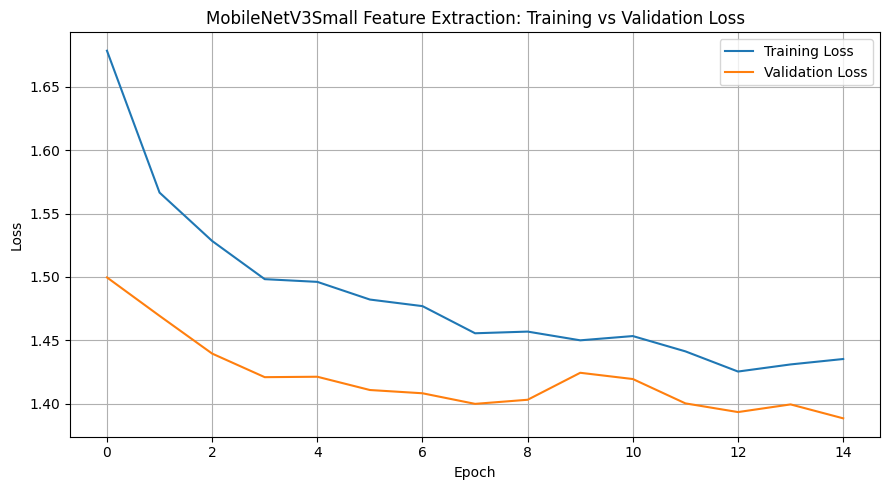

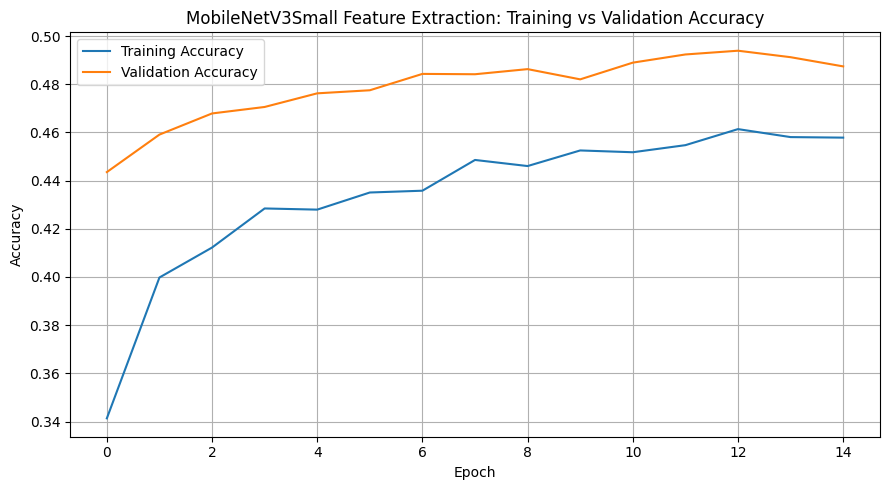

In [ ]:
#  Stage 1: Feature extraction

FEATURE_EPOCHS = 15

start_time = time.time()
transfer_history = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=FEATURE_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks(
        "transfer_feature_extraction",
        monitor="val_accuracy",
        mode="max",
        patience=5
    ),
    verbose=1
)
transfer_feature_time = time.time() - start_time

print(f"Transfer feature extraction training time: {transfer_feature_time:.2f} seconds")
plot_history(transfer_history, "MobileNetV3Small Feature Extraction")


Total base model layers: 157
Fine-tuning from layer index: 102
Trainable layers in full model: 11
Epoch 1/20
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4746 - loss: 1.3953
Epoch 1: val_accuracy improved from None to 0.51642, saving model to transfer_fine_tuned_best.keras

Epoch 1: finished saving model to transfer_fine_tuned_best.keras
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 66s 33ms/step - accuracy: 0.4810 - loss: 1.3776 - val_accuracy: 0.5164 - val_loss: 1.3195 - learning_rate: 1.0000e-05
Epoch 2/20
1679/1680 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4939 - loss: 1.3406
Epoch 2: val_accuracy improved from 0.51642 to 0.52646, saving model to transfer_fine_tuned_best.keras

Epoch 2: finished saving model to transfer_fine_tuned_best.keras
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 58s 35ms/step - accuracy: 0.4964 - loss: 1.3391 - val_accuracy: 0.5265 - val_loss: 1.2937 - learning_rate: 1.0000e-05
Epoch 3/20
1678/1680 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5065 - loss: 1.3229
Ep

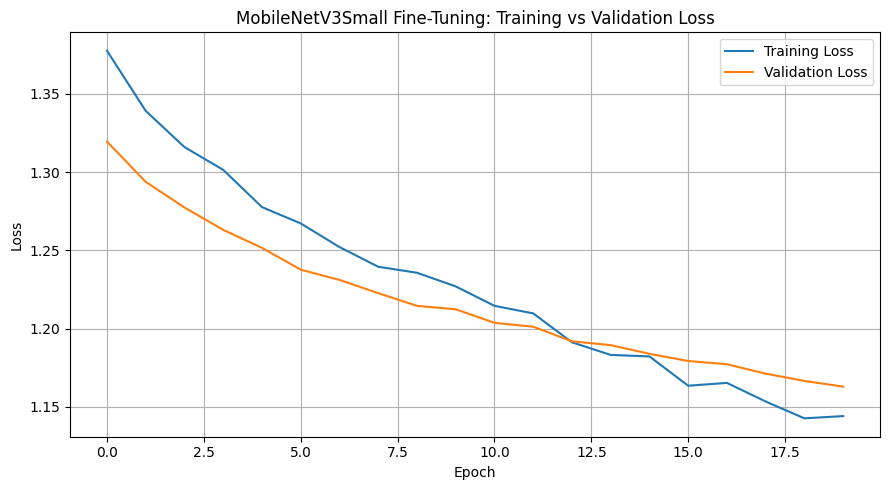

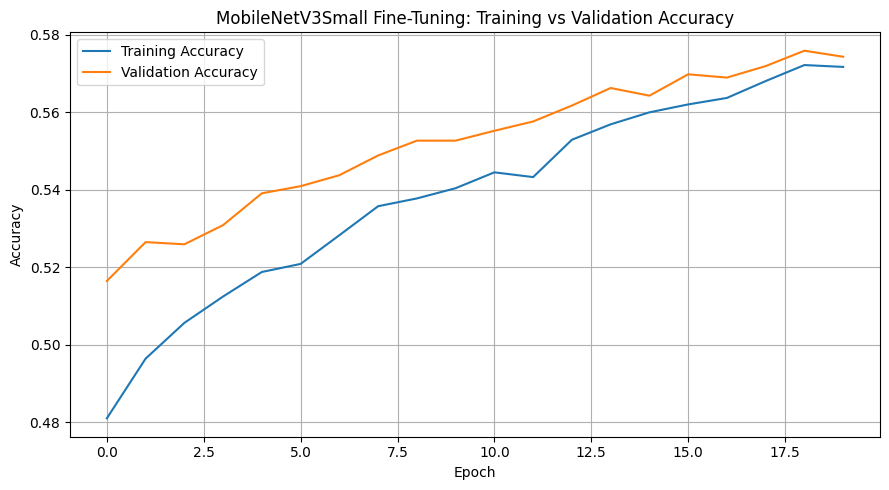

In [ ]:
#  Stage 2: Fine-tuning upper layers

base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.65)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Total base model layers:", len(base_model.layers))
print("Fine-tuning from layer index:", fine_tune_at)
print("Trainable layers in full model:", sum(layer.trainable for layer in transfer_model.layers))

FINE_TUNE_EPOCHS = 20

start_time = time.time()
fine_tune_history = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks(
        "transfer_fine_tuned",
        monitor="val_accuracy",
        mode="max",
        patience=6
    ),
    verbose=1
)
transfer_fine_tune_time = time.time() - start_time

print(f"Transfer fine-tuning time: {transfer_fine_tune_time:.2f} seconds")
plot_history(fine_tune_history, "MobileNetV3Small Fine-Tuning")



MobileNetV3Small + PointAttention Transfer Learning Evaluation
------------------------------------------------------------
Test loss: 1.3020
Test accuracy: 0.5284
Weighted precision: 0.5327
Weighted recall: 0.5284
Weighted F1-score: 0.5093
Macro precision: 0.5542
Macro recall: 0.5200
Macro F1-score: 0.5138

Classification Report:
              precision    recall  f1-score   support

       angry       0.48      0.48      0.48       300
     disgust       0.76      0.44      0.56       100
        fear       0.49      0.15      0.23       300
       happy       0.68      0.80      0.74       300
     neutral       0.43      0.65      0.52       300
         sad       0.37      0.39      0.38       300
    surprise       0.67      0.73      0.70       300

    accuracy                           0.53      1900
   macro avg       0.55      0.52      0.51      1900
weighted avg       0.53      0.53      0.51      1900



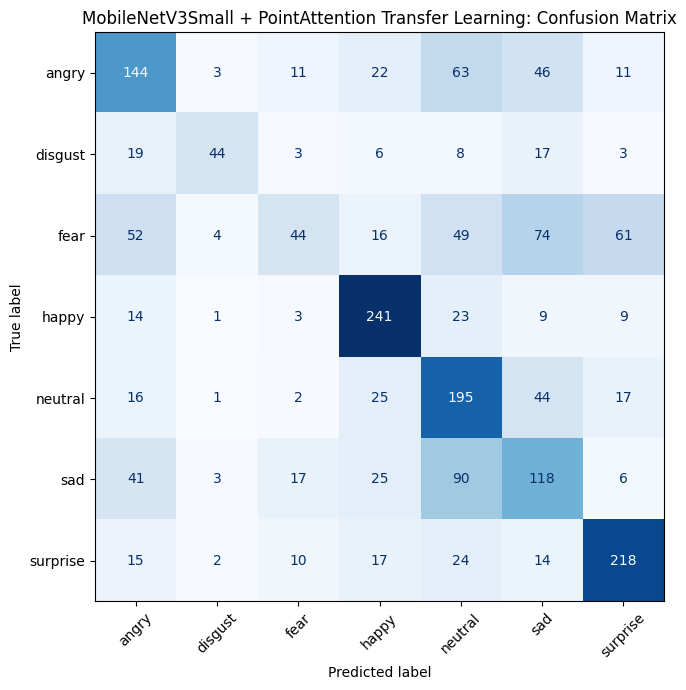

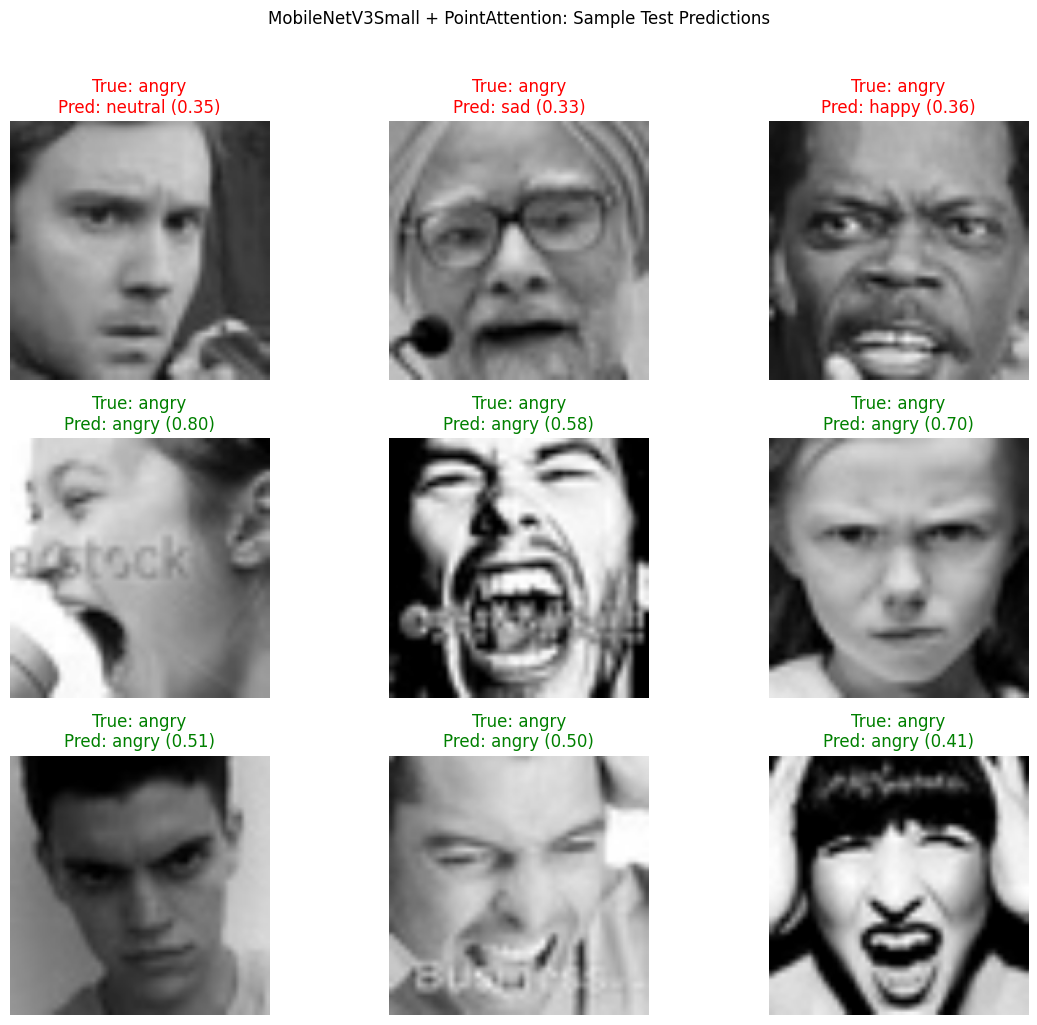

In [ ]:
#  Evaluate transfer model

transfer_metrics, transfer_y_true, transfer_y_pred, transfer_y_prob = evaluate_model(
    transfer_model,
    transfer_test_ds,
    class_names,
    "MobileNetV3Small + PointAttention Transfer Learning"
)

transfer_metrics["Training Time (seconds)"] = transfer_feature_time + transfer_fine_tune_time

plot_sample_predictions(
    transfer_model,
    transfer_test_ds,
    class_names,
    title="MobileNetV3Small + PointAttention: Sample Test Predictions"
)


# Final comparative analysis

This section compares the major experiments required in the assignment:
- baseline CNN from scratch
- deeper regularized CNN
- optimizer comparison (SGD vs Adam)
- ablation study
- transfer learning / fine-tuning

Use the output table and plots below as evidence for the report discussion on:
- model accuracy and loss
- optimizer behavior
- regularization effects
- computational trade-offs
- whether transfer learning outperforms training from scratch

,Model,Test Loss,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1,Training Time (seconds)
0,Baseline CNN,1.2697,0.5305,0.5223,0.5305,0.5208,0.5387,0.5190,0.5203,184.3210
1,Deeper Regularized CNN,1.2130,0.5926,0.5991,0.5926,0.5869,0.6269,0.5829,0.5912,1071.8513
2,Deeper CNN with SGD,1.3576,0.5295,0.5376,0.5295,0.5115,0.5465,0.5067,0.5006,404.2786
3,Deeper CNN with Adam,1.2767,0.5532,0.5496,0.5532,0.5396,0.5750,0.5300,0.5310,447.2271
4,Ablation: Deeper CNN without Dropout,1.2428,0.5905,0.5962,0.5905,0.5853,0.6188,0.5724,0.5810,402.1852
5,MobileNetV3Small + PointAttention Transfer Lea...,1.3020,0.5284,0.5327,0.5284,0.5093,0.5542,0.5200,0.5138,1864.9972


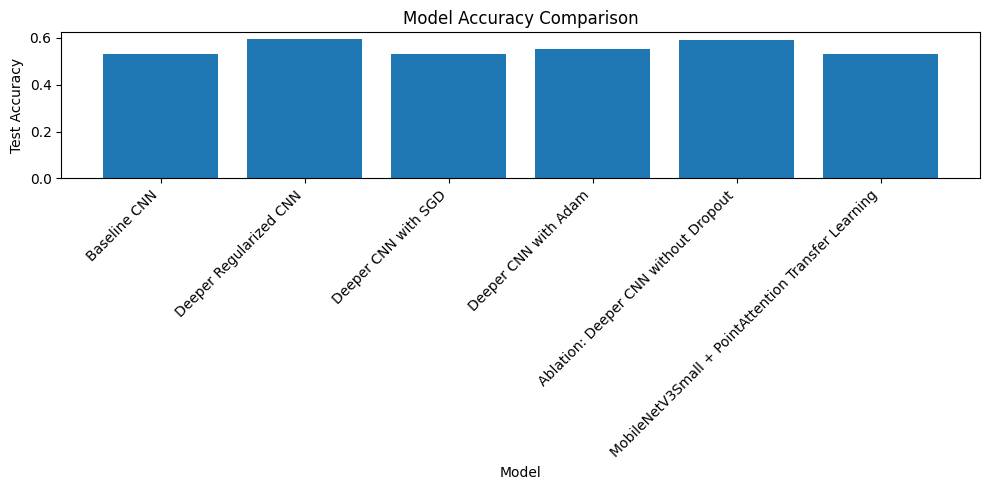

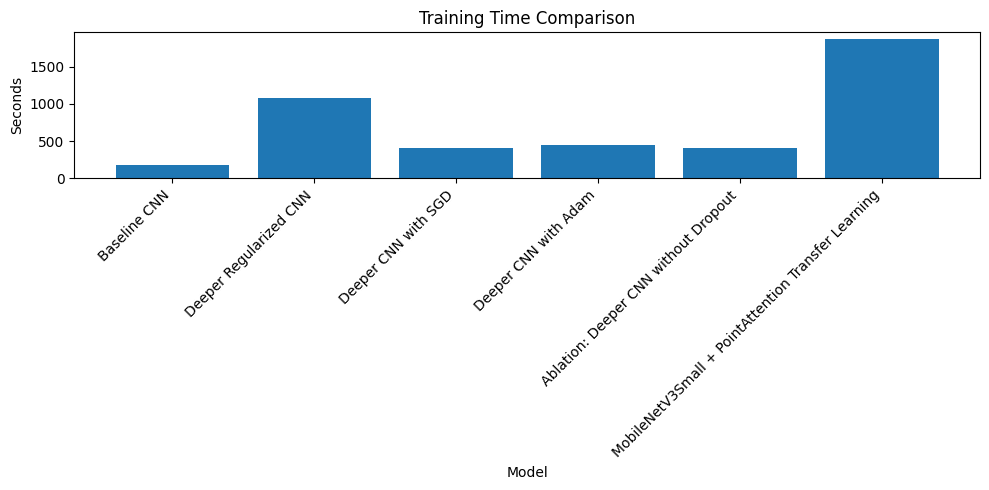

In [ ]:
#  Final comparison table

baseline_metrics["Training Time (seconds)"] = baseline_training_time
deeper_metrics["Training Time (seconds)"] = deeper_training_time

comparison_df = pd.DataFrame([
    baseline_metrics,
    deeper_metrics,
    sgd_metrics,
    adam_metrics,
    ablation_metrics,
    transfer_metrics
])

numeric_cols = comparison_df.select_dtypes(include=[np.number]).columns
comparison_df[numeric_cols] = comparison_df[numeric_cols].round(4)

display(comparison_df)

plt.figure(figsize=(10, 5))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(comparison_df["Model"], comparison_df["Training Time (seconds)"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Best model based on test accuracy: Deeper Regularized CNN
Number of misclassified examples: 774


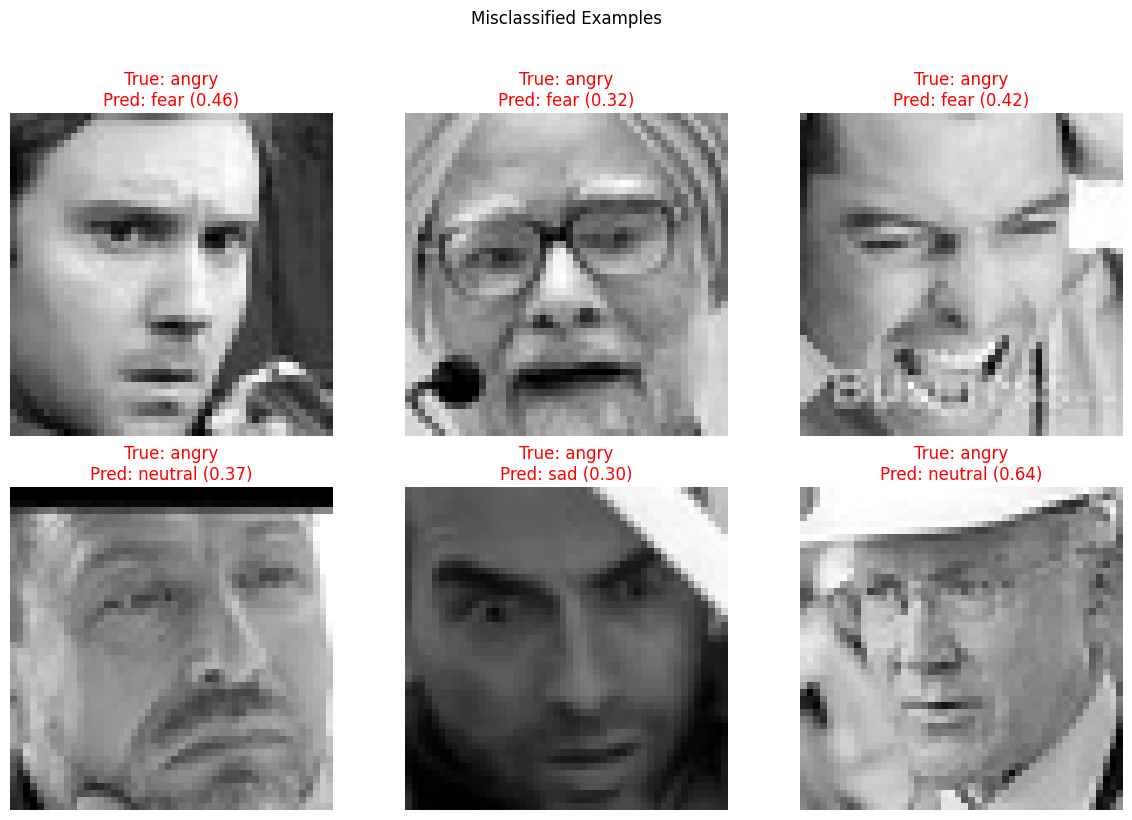

In [ ]:

#  Misclassification analysis for the best model
best_row = comparison_df.sort_values("Test Accuracy", ascending=False).iloc[0]
best_model_name = best_row["Model"]
print("Best model based on test accuracy:", best_model_name)

if "Transfer Learning" in best_model_name:
    best_model = transfer_model
    best_dataset = transfer_test_ds
else:
    # For simplicity, use the deeper model for scratch-model error analysis.
    # You can change this manually to baseline_model, sgd_model or adam_model if needed.
    best_model = deeper_model
    best_dataset = test_ds

all_images = []
all_true = []
for images, labels in best_dataset:
    all_images.append(images.numpy())
    all_true.append(labels.numpy())

all_images = np.concatenate(all_images, axis=0)
all_true = np.concatenate(all_true, axis=0)

all_probs = best_model.predict(best_dataset, verbose=0)
all_pred = np.argmax(all_probs, axis=1)

wrong_indices = np.where(all_true != all_pred)[0]
print("Number of misclassified examples:", len(wrong_indices))

plt.figure(figsize=(12, 8))
for plot_i, idx in enumerate(wrong_indices[:6], start=1):
    plt.subplot(2, 3, plot_i)
    img = all_images[idx]

    if img.shape[-1] == 1:
        plt.imshow(np.squeeze(img), cmap="gray")
    else:
        # Transfer dataset images are RGB and still in 0-255 range before model preprocessing.
        plt.imshow(img.astype("uint8"))

    true_label = class_names[int(all_true[idx])]
    pred_label = class_names[int(all_pred[idx])]
    confidence = np.max(all_probs[idx])

    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})", color="red")
    plt.axis("off")

plt.suptitle("Misclassified Examples", y=1.02)
plt.tight_layout()
plt.show()


## Observations to write after running the notebook

After executing all cells, replace these prompts with your own findings in the report:

1. **Baseline CNN:** Did the simple three-convolution design underfit or generalize reasonably?
2. **Deeper CNN:** Did the extra convolutional blocks, batch normalization, dropout, and L2 improve validation/test performance?
3. **Optimizer comparison:** Which optimizer converged faster, and which one gave the stronger final generalization?
4. **Ablation study:** What happened when dropout was removed? Did overfitting become more visible?
5. **Transfer learning:** Did the MobileNetV3Large + PointAttention model outperform the scratch models?
6. **Efficiency trade-off:** Was the best-performing model also the slowest to train?
7. **Hardware note:** Mention whether you used CPU, GPU, or TPU when reporting total training time.

In [ ]:
#  Save final trained models

SAVE_DIR = "/content/drive/MyDrive/AI ML//vision_task_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

baseline_model.save(os.path.join(SAVE_DIR, "baseline_cnn_improved.keras"))
deeper_model.save(os.path.join(SAVE_DIR, "deeper_regularized_cnn.keras"))
transfer_model.save(os.path.join(SAVE_DIR, "mobilenetv3small_pointattention_transfer.keras"))

comparison_df.to_csv(os.path.join(SAVE_DIR, "model_comparison_results.csv"), index=False)

print("Saved models and comparison table to:", SAVE_DIR)


Saved models and comparison table to: /content/drive/MyDrive/AI-ML COURSEWORK/coursework/vision_task_outputs
